Dependence on primary cosmic ray flux
-----------------------------------

Compares sea-level muon and neutrino fluxes for several CR primary composition models (H3a, Gaisser-Hillas, proton/nuclei).


In [1]:
# import primary model choices
import crflux.models as pm
import matplotlib.pyplot as plt
import os
import tempfile
import numpy as np

# Run against the CI/smallest database (the default download is 292 MB).
from MCEq import config

config.mceq_db_fname = "mceq_db_v140reduced_compact.h5"

# import solver related modules
from MCEq.core import MCEqRun

Create an instance of an MCEqRun class. Most options are defined in the `mceq_config` module, and do not require change. Look into `mceq_config.py` or use the documentation.

If the initialization succeeds it will print out some information according to the debug level. 

In [2]:
mceq_run = MCEqRun(
    # provide the string of the interaction model
    interaction_model="SIBYLL21",
    # primary cosmic ray flux model
    # support a tuple (primary model class (not instance!), arguments)
    primary_model=(pm.HillasGaisser2012, "H3a"),
    # Zenith angle in degrees. 0=vertical, 90=horizontal
    theta_deg=0.0,
)

MCEqRun::set_interaction_model(): SIBYLL21
Interactions::clear_channel_overrides(): 0 channel overrides cleared.
ParticleManager::_init_default_tracking(): Initializing default tracking categories (pi, K, mu)
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('BK_USStd', None)


InitialState::set_primary_model(): Primary model set to Hillas-Gaisser (H3a)


Solve and store results
----------------------

This code below computes fluxes of neutrinos, averaged over all directions, for different primary models.

In [3]:
# Bump up the debug level to see what the calculation is doing
config.debug_level = 2

In [4]:
# Define equidistant grid in cos(theta)
angles = np.arccos(np.linspace(1, 0, 11)) * 180.0 / np.pi

# Power of energy to scale the flux
mag = 3

# obtain energy grid (nver changes) of the solution for the x-axis of the plots
e_grid = mceq_run.e_grid

p_spectrum_flux = []

# Initialize empty grid
for pmcount, pmodel in enumerate(
    [
        (pm.HillasGaisser2012, "H3a"),
        (pm.HillasGaisser2012, "H4a"),
        (pm.GaisserStanevTilav, "3-gen"),
        (pm.GaisserStanevTilav, "4-gen"),
    ]
):
    mceq_run.set_primary_model(*pmodel)

    flux = {}
    for frac in [
        "mu_conv",
        "mu_pr",
        "mu_total",
        "numu_conv",
        "numu_pr",
        "numu_total",
        "nue_conv",
        "nue_pr",
        "nue_total",
        "nutau_pr",
    ]:
        flux[frac] = np.zeros_like(e_grid)

    # Sum fluxes, calculated for different angles
    for theta in angles:
        mceq_run.set_zenith_azimuth(theta)
        mceq_run.solve()
        # _conv means conventional (mostly pions and kaons)
        flux["mu_conv"] += mceq_run.get_solution(
            "conv_mu+", mag
        ) + mceq_run.get_solution("conv_mu-", mag)

        # _pr means prompt (the mother of the muon had a critical energy
        # higher than a D meson. Includes all charm and direct resonance
        # contribution)
        flux["mu_pr"] += mceq_run.get_solution("pr_mu+", mag) + mceq_run.get_solution(
            "pr_mu-", mag
        )

        # total means conventional + prompt
        flux["mu_total"] += mceq_run.get_solution(
            "total_mu+", mag
        ) + mceq_run.get_solution("total_mu-", mag)

        # same meaning of prefixes for muon neutrinos as for muons
        flux["numu_conv"] += mceq_run.get_solution(
            "conv_numu", mag
        ) + mceq_run.get_solution("conv_antinumu", mag)

        flux["numu_pr"] += mceq_run.get_solution(
            "pr_numu", mag
        ) + mceq_run.get_solution("pr_antinumu", mag)

        flux["numu_total"] += mceq_run.get_solution(
            "total_numu", mag
        ) + mceq_run.get_solution("total_antinumu", mag)

        # same meaning of prefixes for electron neutrinos as for muons
        flux["nue_conv"] += mceq_run.get_solution(
            "conv_nue", mag
        ) + mceq_run.get_solution("conv_antinue", mag)

        flux["nue_pr"] += mceq_run.get_solution("pr_nue", mag) + mceq_run.get_solution(
            "pr_antinue", mag
        )

        flux["nue_total"] += mceq_run.get_solution(
            "total_nue", mag
        ) + mceq_run.get_solution("total_antinue", mag)

        # since there are no conventional tau neutrinos, prompt=total
        flux["nutau_pr"] += mceq_run.get_solution(
            "total_nutau", mag
        ) + mceq_run.get_solution("total_antinutau", mag)

    # average the results
    for frac in [
        "mu_conv",
        "mu_pr",
        "mu_total",
        "numu_conv",
        "numu_pr",
        "numu_total",
        "nue_conv",
        "nue_pr",
        "nue_total",
        "nutau_pr",
    ]:
        flux[frac] = flux[frac] / float(len(angles))

    p_spectrum_flux.append((flux, mceq_run.pmodel.sname, mceq_run.pmodel.name))

InitialState::set_primary_model(): Primary model set to Hillas-Gaisser (H3a)
MCEqRun::set_zenith_azimuth(): Zenith angle   0.00
MCEqRun::set_zenith_azimuth(): Angle selection corresponds to cached value, skipping calc.
MCEqRun::solve(): Launching numpy_etd2 solver
calculate_integration_path(): ETD2 non-uniform path (eps=0.3, dX_max=20.0, dX_min=0.01, fd_span=0.01, X_start=0.0)
MCEqRun::solve(): for 81 integration steps.
etd2_driver(): Performance (numpy K=1):   0.44ms/iteration ( 0.444ms/iteration/RHS)
MCEqRun::solve(): time elapsed during integration:  0.04sec
MCEqRun::set_zenith_azimuth(): Zenith angle  25.84
MCEqRun::solve(): Launching numpy_etd2 solver
calculate_integration_path(): ETD2 non-uniform path (eps=0.3, dX_max=20.0, dX_min=0.01, fd_span=0.01, X_start=0.0)
MCEqRun::solve(): for 87 integration steps.


etd2_driver(): Performance (numpy K=1):   0.45ms/iteration ( 0.453ms/iteration/RHS)
MCEqRun::solve(): time elapsed during integration:  0.04sec
MCEqRun::set_zenith_azimuth(): Zenith angle  36.87
MCEqRun::solve(): Launching numpy_etd2 solver
calculate_integration_path(): ETD2 non-uniform path (eps=0.3, dX_max=20.0, dX_min=0.01, fd_span=0.01, X_start=0.0)
MCEqRun::solve(): for 94 integration steps.
etd2_driver(): Performance (numpy K=1):   0.44ms/iteration ( 0.443ms/iteration/RHS)
MCEqRun::solve(): time elapsed during integration:  0.04sec
MCEqRun::set_zenith_azimuth(): Zenith angle  45.57
MCEqRun::solve(): Launching numpy_etd2 solver
calculate_integration_path(): ETD2 non-uniform path (eps=0.3, dX_max=20.0, dX_min=0.01, fd_span=0.01, X_start=0.0)
MCEqRun::solve(): for 103 integration steps.
etd2_driver(): Performance (numpy K=1):   0.44ms/iteration ( 0.445ms/iteration/RHS)
MCEqRun::solve(): time elapsed during integration:  0.05sec
MCEqRun::set_zenith_azimuth(): Zenith angle  53.13
MCEq

etd2_driver(): Performance (numpy K=1):   0.45ms/iteration ( 0.449ms/iteration/RHS)
MCEqRun::solve(): time elapsed during integration:  0.05sec
MCEqRun::set_zenith_azimuth(): Zenith angle  60.00
MCEqRun::solve(): Launching numpy_etd2 solver
calculate_integration_path(): ETD2 non-uniform path (eps=0.3, dX_max=20.0, dX_min=0.01, fd_span=0.01, X_start=0.0)
MCEqRun::solve(): for 133 integration steps.
etd2_driver(): Performance (numpy K=1):   0.44ms/iteration ( 0.442ms/iteration/RHS)
MCEqRun::solve(): time elapsed during integration:  0.06sec
MCEqRun::set_zenith_azimuth(): Zenith angle  66.42
MCEqRun::solve(): Launching numpy_etd2 solver
calculate_integration_path(): ETD2 non-uniform path (eps=0.3, dX_max=20.0, dX_min=0.01, fd_span=0.01, X_start=0.0)
MCEqRun::solve(): for 158 integration steps.


etd2_driver(): Performance (numpy K=1):   0.44ms/iteration ( 0.443ms/iteration/RHS)
MCEqRun::solve(): time elapsed during integration:  0.07sec
MCEqRun::set_zenith_azimuth(): Zenith angle  72.54
MCEqRun::solve(): Launching numpy_etd2 solver
calculate_integration_path(): ETD2 non-uniform path (eps=0.3, dX_max=20.0, dX_min=0.01, fd_span=0.01, X_start=0.0)
MCEqRun::solve(): for 200 integration steps.
etd2_driver(): Performance (numpy K=1):   0.44ms/iteration ( 0.443ms/iteration/RHS)
MCEqRun::solve(): time elapsed during integration:  0.09sec
MCEqRun::set_zenith_azimuth(): Zenith angle  78.46
MCEqRun::solve(): Launching numpy_etd2 solver
calculate_integration_path(): ETD2 non-uniform path (eps=0.3, dX_max=20.0, dX_min=0.01, fd_span=0.01, X_start=0.0)
MCEqRun::solve(): for 281 integration steps.


etd2_driver(): Performance (numpy K=1):   0.44ms/iteration ( 0.444ms/iteration/RHS)
MCEqRun::solve(): time elapsed during integration:  0.13sec
MCEqRun::set_zenith_azimuth(): Zenith angle  84.26
MCEqRun::solve(): Launching numpy_etd2 solver
calculate_integration_path(): ETD2 non-uniform path (eps=0.3, dX_max=20.0, dX_min=0.01, fd_span=0.01, X_start=0.0)
MCEqRun::solve(): for 500 integration steps.


...

etd2_driver(): Performance (numpy K=1):   0.45ms/iteration ( 0.447ms/iteration/RHS)
MCEqRun::solve(): time elapsed during integration:  0.05sec
MCEqRun::set_zenith_azimuth(): Zenith angle  60.00
MCEqRun::solve(): Launching numpy_etd2 solver
calculate_integration_path(): ETD2 non-uniform path (eps=0.3, dX_max=20.0, dX_min=0.01, fd_span=0.01, X_start=0.0)
MCEqRun::solve(): for 133 integration steps.
etd2_driver(): Performance (numpy K=1):   0.44ms/iteration ( 0.438ms/iteration/RHS)
MCEqRun::solve(): time elapsed during integration:  0.06sec
MCEqRun::set_zenith_azimuth(): Zenith angle  66.42
MCEqRun::solve(): Launching numpy_etd2 solver
calculate_integration_path(): ETD2 non-uniform path (eps=0.3, dX_max=20.0, dX_min=0.01, fd_span=0.01, X_start=0.0)
MCEqRun::solve(): for 158 integration steps.


etd2_driver(): Performance (numpy K=1):   0.47ms/iteration ( 0.470ms/iteration/RHS)
MCEqRun::solve(): time elapsed during integration:  0.07sec
MCEqRun::set_zenith_azimuth(): Zenith angle  72.54
MCEqRun::solve(): Launching numpy_etd2 solver
calculate_integration_path(): ETD2 non-uniform path (eps=0.3, dX_max=20.0, dX_min=0.01, fd_span=0.01, X_start=0.0)
MCEqRun::solve(): for 200 integration steps.
etd2_driver(): Performance (numpy K=1):   0.44ms/iteration ( 0.442ms/iteration/RHS)
MCEqRun::solve(): time elapsed during integration:  0.09sec
MCEqRun::set_zenith_azimuth(): Zenith angle  78.46
MCEqRun::solve(): Launching numpy_etd2 solver
calculate_integration_path(): ETD2 non-uniform path (eps=0.3, dX_max=20.0, dX_min=0.01, fd_span=0.01, X_start=0.0)
MCEqRun::solve(): for 281 integration steps.


etd2_driver(): Performance (numpy K=1):   0.44ms/iteration ( 0.443ms/iteration/RHS)
MCEqRun::solve(): time elapsed during integration:  0.12sec
MCEqRun::set_zenith_azimuth(): Zenith angle  84.26
MCEqRun::solve(): Launching numpy_etd2 solver
calculate_integration_path(): ETD2 non-uniform path (eps=0.3, dX_max=20.0, dX_min=0.01, fd_span=0.01, X_start=0.0)
MCEqRun::solve(): for 500 integration steps.


etd2_driver(): Performance (numpy K=1):   0.44ms/iteration ( 0.443ms/iteration/RHS)
MCEqRun::solve(): time elapsed during integration:  0.22sec
MCEqRun::set_zenith_azimuth(): Zenith angle  90.00
MCEqRun::solve(): Launching numpy_etd2 solver
calculate_integration_path(): ETD2 non-uniform path (eps=0.3, dX_max=20.0, dX_min=0.01, fd_span=0.01, X_start=0.0)
MCEqRun::solve(): for 1854 integration steps.


etd2_driver(): Performance (numpy K=1):   0.44ms/iteration ( 0.442ms/iteration/RHS)
MCEqRun::solve(): time elapsed during integration:  0.82sec


Plot with matplotlib
--------------------

In [5]:
# Sample tables go to a temporary directory (CI-runnable).
desktop = tempfile.mkdtemp(prefix="mceq_example_")

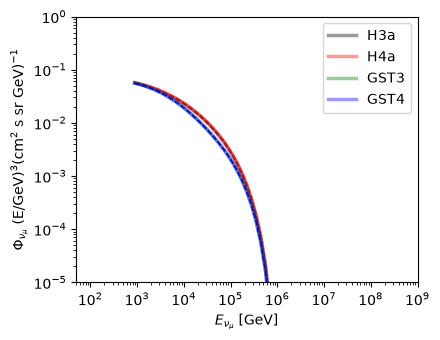

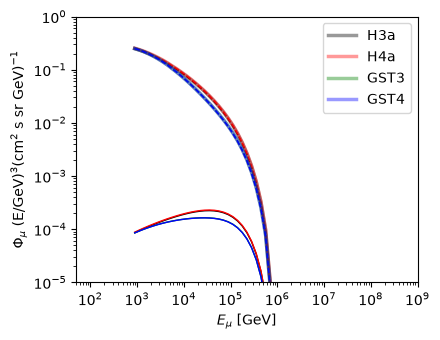

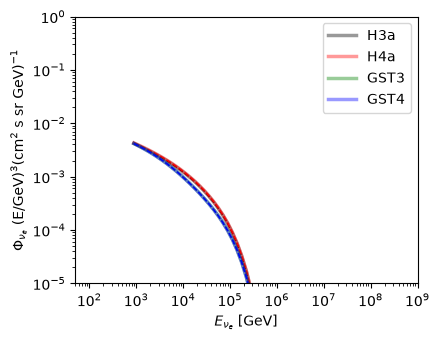

In [6]:
for pref, lab in [("numu_", r"\nu_\mu"), ("mu_", r"\mu"), ("nue_", r"\nu_e")]:
    plt.figure(figsize=(4.5, 3.5))
    for (flux, p_sname, p_name), col in zip(p_spectrum_flux, ["k", "r", "g", "b", "c"]):
        plt.loglog(
            e_grid,
            flux[pref + "total"],
            color=col,
            ls="-",
            lw=2.5,
            label=p_sname,
            alpha=0.4,
        )
        plt.loglog(
            e_grid, flux[pref + "conv"], color=col, ls="--", lw=1, label="_nolabel_"
        )
        plt.loglog(
            e_grid, flux[pref + "pr"], color=col, ls="-", lw=1, label="_nolabel_"
        )
    plt.xlim(50, 1e9)
    plt.ylim(1e-5, 1)
    plt.xlabel(rf"$E_{{{lab}}}$ [GeV]")
    plt.ylabel(
        r"$\Phi_{"
        + lab
        + "}$ (E/GeV)$^{"
        + str(mag)
        + " }$"
        + "(cm$^{2}$ s sr GeV)$^{-1}$"
    )
    plt.legend(loc="upper right")
    plt.tight_layout()

    # Uncoment if you want to save the plot
    # plt.savefig(os.path.join(desktop,pref + 'flux.pdf'))

Save as in ASCII file for other types of processing
---------------------------------------------------

In [7]:
for flux, p_sname, p_name in p_spectrum_flux:
    np.savetxt(
        open(os.path.join(desktop, "numu_flux_" + p_sname + ".txt"), "w"),
        np.column_stack((
            e_grid,
            flux["mu_conv"],
            flux["mu_pr"],
            flux["mu_total"],
            flux["numu_conv"],
            flux["numu_pr"],
            flux["numu_total"],
            flux["nue_conv"],
            flux["nue_pr"],
            flux["nue_total"],
            flux["nutau_pr"],
        )),
        fmt="%6.5E",
        header=(
            "lepton flux scaled with E**{0}. Order (E, mu_conv, mu_pr, mu_total, "
            + "numu_conv, numu_pr, numu_total, nue_conv, nue_pr, nue_total, "
            + "nutau_pr"
        ).format(mag),
    )